<a href="https://colab.research.google.com/github/kite121/Kaggle_competitions/blob/main/Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
checkpoint_path = "/content/drive/MyDrive/ml_checkpoints/model.pth"
import os
os.makedirs("/content/drive/MyDrive/ml_checkpoints", exist_ok=True)


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("/content/Train_test_data/train.csv")

In [8]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
#Change PassengerId on just Pasenger grop, like gggg_pp on gggg
#Home Planet put with random based on the probability from frequency of planets
# Put in the same way, with probability
# Cabin

In [10]:
df.isna().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [257]:
def df_all_aplied(df):
  df["PassengerId"] = df["PassengerId"].dropna()
  df["PassengerId"] = df["PassengerId"].apply(lambda x: x.split("_")[0])
  df[["deck", "num", "side"]] = df["Cabin"].apply(
    lambda x: pd.Series(str(x).split("/")) if pd.notna(x) else pd.Series([np.nan, np.nan, np.nan])
)
  columns_for_weights = ["PassengerId", "HomePlanet", "CryoSleep", "Destination", "VIP", "deck", "side"]
  for name in columns_for_weights:
    replace_nans_with_weights(df, name)
  df.drop(columns=["Cabin"], inplace = True)
  df.loc[df["num"].isna(), "num"] = np.random.randint(0, 1895)
  df.loc[df["num"].notna(), "num"] = df.loc[df["num"].notna(), "num"].astype(int)
  df.loc[df["Age"].isna(), "Age"] = df["Age"].dropna().mean()
  special_attr = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
  for col in special_attr:
    df[col + "_was_nan"] = df[col].isna().astype(int)
    low = df[col].quantile(0.01)
    df[col] = df[col].fillna(np.random.uniform(0, low))
  df[["First_name", "Last_name"]] = df["Name"].apply(
    lambda x: pd.Series(str(x).split(" ")) if pd.notna(x) else pd.Series([np.nan, np.nan])
)
  df[["First_name", "Last_name"]] = df[["First_name", "Last_name"]].fillna("Unknown")
  df.drop(columns = ["Name", "First_name"], inplace = True)



In [240]:
def replace_nans_with_weights(df, name):
  frequency = Counter(df[name].dropna())
  sum_of_all = len(df[name].dropna())
  classes = []
  prob = []
  for key, value in frequency.items():
    classes.append(key)
    prob.append(value / sum_of_all)
  df.loc[df[name].isna(), name] = np.random.choice(classes, p = prob)

In [93]:
digital_cols = df.select_dtypes(include = "number").columns
digital_cols_first_group = ["PassengerId", "Age", "num"]
digital_cols_second_group = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
categorical_cols = df.select_dtypes(exclude = "number").columns
assert len(digital_cols) + len(categorical_cols) == len(df.columns)

In [27]:
#Passenger_Id - good
#Age - partially good
#Num - good
#Definitely need to use StandardScaler because most of the features have outliers and different values

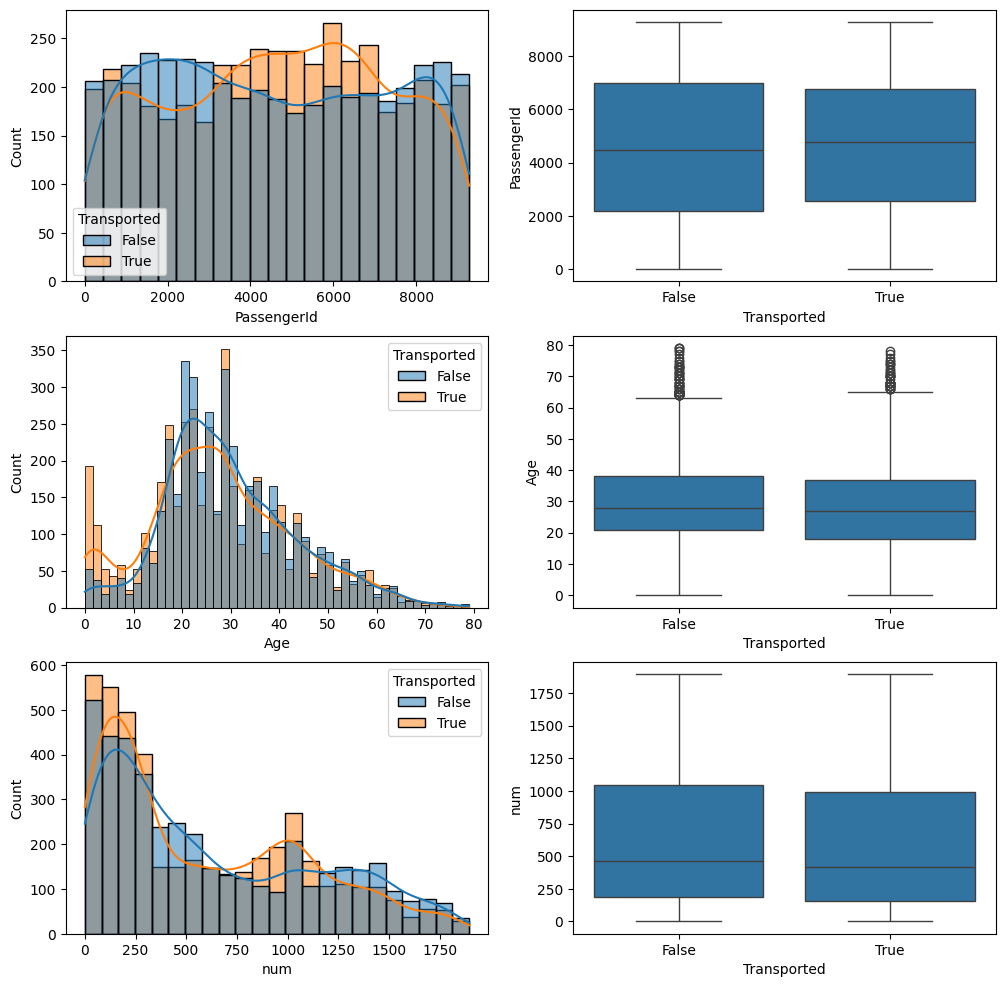

In [28]:
fig, axes = plt.subplots(len(digital_cols_first_group), 2, figsize = (12, 12))
for i in range(len(digital_cols_first_group)):
  col = digital_cols_first_group[i]
  sns.histplot(df, x=col, hue="Transported", kde=True, ax = axes[i][0])
  sns.boxplot(x="Transported", y=col, data=df, ax = axes[i][1])


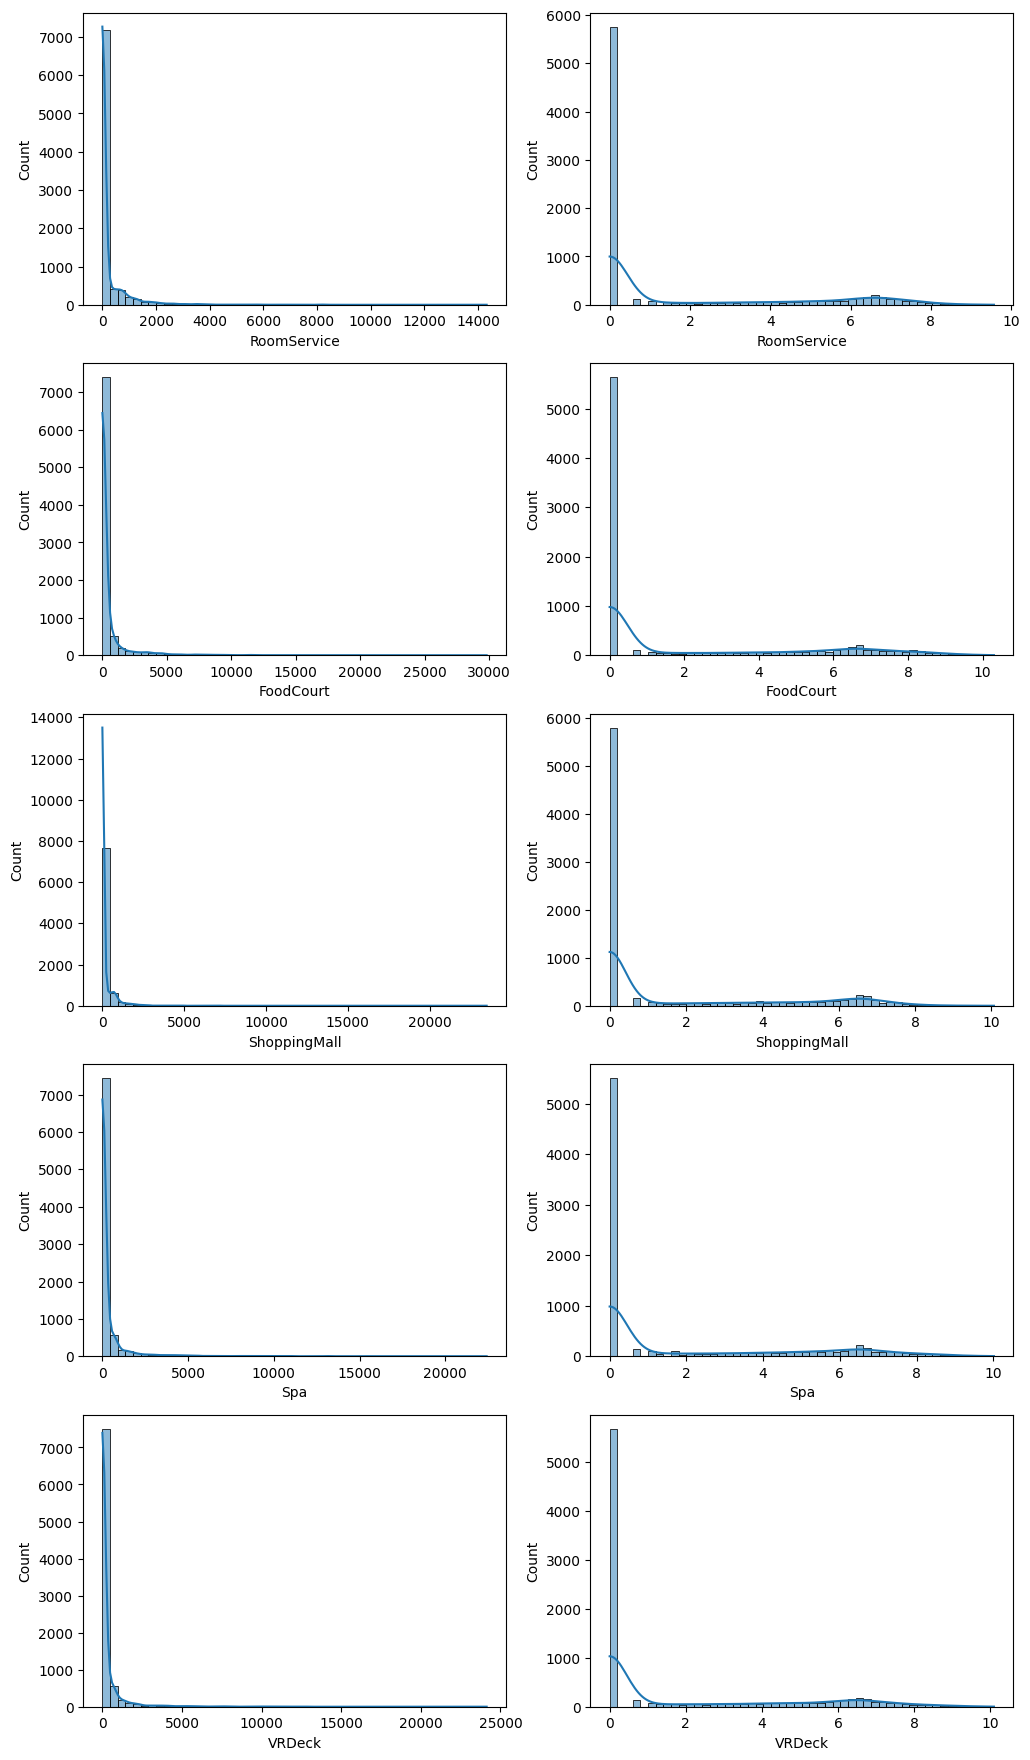

In [29]:
fig, axes = plt.subplots(len(digital_cols_second_group), 2, figsize = (12, 22))
for i in range(len(digital_cols_second_group)):
  col = digital_cols_second_group[i]
  sns.histplot(df[col], ax = axes[i][0], bins = 50, kde = True)
  sns.histplot(np.log1p(df[col]), ax = axes[i][1], bins = 50, kde = True)


In [43]:
for col in categorical_cols:
  print(df[col].value_counts().nlargest(20))

HomePlanet
Earth     4803
Europa    2131
Mars      1759
Name: count, dtype: int64
CryoSleep
False    5656
True     3037
Name: count, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1982
PSO J318.5-22     796
Name: count, dtype: int64
VIP
False    8494
True      199
Name: count, dtype: int64
Transported
True     4378
False    4315
Name: count, dtype: int64
deck
F    2794
G    2559
C     946
E     876
B     779
D     478
A     256
T       5
Name: count, dtype: int64
side
S    4487
P    4206
Name: count, dtype: int64
Last_name
Unknown        200
Casonston       18
Oneiles         16
Litthews        15
Domington       15
Cartez          14
Garnes          14
Browlerson      14
Fulloydez       14
Moodman         13
Briggston       13
Gibbsonton      13
Hinglendez      13
Barbes          13
Distured        13
Fowlesterez     12
Vloaf           12
Hanner          12
Loway           12
Vandan          12
Name: count, dtype: int64


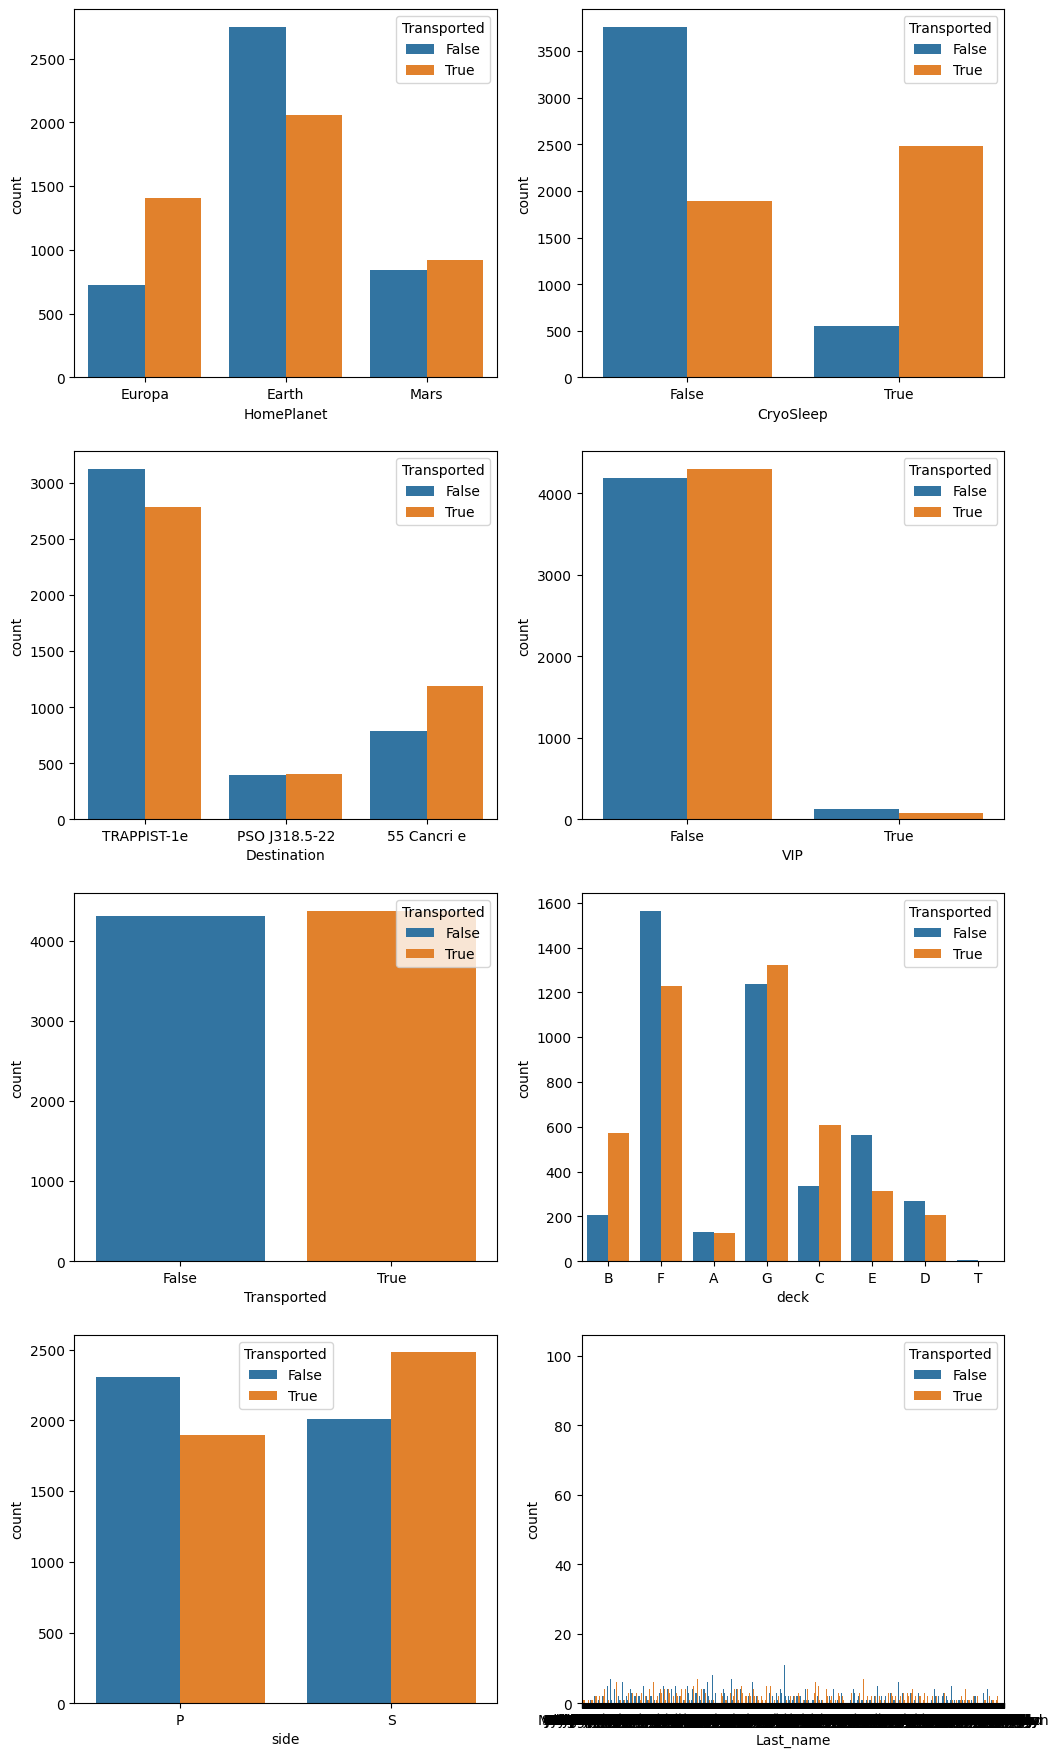

In [48]:
fig, axes = plt.subplots(4, 2, figsize = (12, 22))
counter_i = 0
counter_j = 0
for i in range(len(categorical_cols)):
  if counter_j == 2:
    counter_i += 1
    counter_j = 0
  col = categorical_cols[i]
  sns.countplot(x=col, data=df, hue = "Transported", ax = axes[counter_i][counter_j])
  counter_j += 1

In [64]:
for i in range(len(categorical_cols)):
  col = categorical_cols[i]
  print(pd.crosstab(df[col], df["Transported"], normalize = "index"))

Transported     False     True 
HomePlanet                     
Earth        0.572351  0.427649
Europa       0.341154  0.658846
Mars         0.476976  0.523024
Transported     False     True 
CryoSleep                      
False        0.664958  0.335042
True         0.182417  0.817583
Transported       False     True 
Destination                      
55 Cancri e    0.399596  0.600404
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175
Transported     False     True 
VIP                            
False        0.493525  0.506475
True         0.618090  0.381910
Transported  False  True 
Transported              
False          1.0    0.0
True           0.0    1.0
Transported     False     True 
deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.357294  0.642706
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.439871
G            0.483783  0.516217
T            0.800000 

In [63]:
rare = df["Last_name"].value_counts()
rare = rare[rare < 10].index
df["Last_name"] = df["Last_name"].where(~df["Last_name"].isin(rare), "Others")
df["Last_name"].value_counts()
pd.crosstab(df["Last_name"], df["Transported"], normalize = "index")

,Others
Transported,
False,0.495155
True,0.504845


In [75]:
features = df.columns.drop("Transported")
X = df[features]
Y = df["Transported"]

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [80]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.2 MB/s eta 0:00:00


In [82]:
from catboost import CatBoostClassifier, Pool

In [94]:
categorical_cols = categorical_cols.to_list()
categorical_cols.remove("Transported")

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'deck', 'side', 'Last_name']

In [95]:
train_pool = Pool(X_train, y_train, cat_features = categorical_cols)
test_pool = Pool(X_val, y_val, cat_features = categorical_cols)


In [184]:
model1 = CatBoostClassifier(iterations = 500, learning_rate = 0.1,
                           depth = 4, eval_metric = "Accuracy", random_seed = 42,
                           verbose = 100, l2_leaf_reg=4)

In [185]:
model1.fit(train_pool, eval_set = test_pool)


0:	learn: 0.7693414	test: 0.7579068	best: 0.7579068 (0)	total: 11.4ms	remaining: 5.67s
100:	learn: 0.8183779	test: 0.7947096	best: 0.7981599 (85)	total: 1.09s	remaining: 4.3s
200:	learn: 0.8311763	test: 0.7935595	best: 0.7981599 (85)	total: 2.12s	remaining: 3.15s
300:	learn: 0.8428243	test: 0.7947096	best: 0.7981599 (85)	total: 3.16s	remaining: 2.09s
400:	learn: 0.8540408	test: 0.8044853	best: 0.8062105 (382)	total: 4.22s	remaining: 1.04s
499:	learn: 0.8651136	test: 0.8033353	best: 0.8067855 (483)	total: 5.25s	remaining: 0us

bestTest = 0.8067855089
bestIteration = 483

Shrink model to first 484 iterations.


In [186]:
model2 = CatBoostClassifier(iterations = 700, learning_rate = 0.05,
                           depth = 4, eval_metric = "Accuracy", random_seed = 42,
                           verbose = 100, l2_leaf_reg=4)

In [187]:
model2.fit(train_pool, eval_set = test_pool, use_best_model = True, init_model = model1)

0:	learn: 0.8543284	test: 0.8062105	best: 0.8062105 (0)	total: 10.7ms	remaining: 7.5s
100:	learn: 0.8554789	test: 0.8067855	best: 0.8067855 (90)	total: 939ms	remaining: 5.57s
200:	learn: 0.8605119	test: 0.8067855	best: 0.8073606 (101)	total: 1.88s	remaining: 4.67s
300:	learn: 0.8628128	test: 0.8085106	best: 0.8085106 (279)	total: 2.83s	remaining: 3.75s
400:	learn: 0.8661202	test: 0.8079356	best: 0.8096607 (353)	total: 3.83s	remaining: 2.86s
500:	learn: 0.8678458	test: 0.8108108	best: 0.8113859 (477)	total: 4.85s	remaining: 1.93s
600:	learn: 0.8688525	test: 0.8085106	best: 0.8113859 (477)	total: 5.91s	remaining: 973ms
699:	learn: 0.8731665	test: 0.8096607	best: 0.8113859 (477)	total: 6.95s	remaining: 0us

bestTest = 0.8113858539
bestIteration = 477

Shrink model to first 478 iterations.


In [188]:
model3 = CatBoostClassifier(iterations = 1000, learning_rate = 0.035,
                           depth = 5, eval_metric = "Accuracy", random_seed = 42,
                           verbose = 100, l2_leaf_reg=4)

In [189]:
model3.fit(train_pool, eval_set = test_pool, use_best_model = True, init_model = model2)

0:	learn: 0.8600805	test: 0.8113859	best: 0.8113859 (0)	total: 22.9ms	remaining: 22.9s
100:	learn: 0.8619500	test: 0.8085106	best: 0.8113859 (0)	total: 1.54s	remaining: 13.7s
200:	learn: 0.8651136	test: 0.8113859	best: 0.8113859 (0)	total: 2.61s	remaining: 10.4s
300:	learn: 0.8685649	test: 0.8108108	best: 0.8131110 (263)	total: 3.71s	remaining: 8.61s
400:	learn: 0.8704343	test: 0.8102358	best: 0.8131110 (263)	total: 4.84s	remaining: 7.23s
500:	learn: 0.8731665	test: 0.8108108	best: 0.8131110 (263)	total: 6.02s	remaining: 6s
600:	learn: 0.8767616	test: 0.8102358	best: 0.8131110 (263)	total: 7.28s	remaining: 4.83s
700:	learn: 0.8797814	test: 0.8096607	best: 0.8131110 (263)	total: 8.61s	remaining: 3.67s
800:	learn: 0.8842393	test: 0.8102358	best: 0.8131110 (263)	total: 9.9s	remaining: 2.46s
900:	learn: 0.8876905	test: 0.8096607	best: 0.8131110 (263)	total: 11.5s	remaining: 1.27s
999:	learn: 0.8909980	test: 0.8062105	best: 0.8131110 (263)	total: 14.1s	remaining: 0us

bestTest = 0.813110983

In [190]:
model4 = CatBoostClassifier(iterations = 1500, learning_rate = 0.02,
                           depth = 4, eval_metric = "Accuracy", random_seed = 42,
                           verbose = 100, l2_leaf_reg=4)

In [191]:
model4.fit(train_pool, eval_set = test_pool, use_best_model = True, init_model = model3)

0:	learn: 0.8616624	test: 0.8131110	best: 0.8131110 (0)	total: 11.1ms	remaining: 16.6s
100:	learn: 0.8622376	test: 0.8131110	best: 0.8142611 (43)	total: 926ms	remaining: 12.8s
200:	learn: 0.8631004	test: 0.8125359	best: 0.8142611 (43)	total: 1.86s	remaining: 12.1s
300:	learn: 0.8643946	test: 0.8136860	best: 0.8142611 (43)	total: 3.34s	remaining: 13.3s
400:	learn: 0.8651136	test: 0.8131110	best: 0.8142611 (43)	total: 5.23s	remaining: 14.3s
500:	learn: 0.8664078	test: 0.8131110	best: 0.8142611 (43)	total: 6.66s	remaining: 13.3s
600:	learn: 0.8678458	test: 0.8131110	best: 0.8142611 (43)	total: 7.58s	remaining: 11.3s
700:	learn: 0.8675582	test: 0.8131110	best: 0.8142611 (43)	total: 8.53s	remaining: 9.72s
800:	learn: 0.8688525	test: 0.8131110	best: 0.8142611 (43)	total: 9.47s	remaining: 8.27s
900:	learn: 0.8697153	test: 0.8131110	best: 0.8142611 (43)	total: 10.9s	remaining: 7.22s
1000:	learn: 0.8705781	test: 0.8125359	best: 0.8142611 (43)	total: 12.2s	remaining: 6.08s
1100:	learn: 0.8704343

In [261]:
X_submission_original = pd.read_csv("/content/Train_test_data/test.csv")

In [258]:
X_submission = pd.read_csv("/content/Train_test_data/test.csv")

In [259]:
df_all_aplied(X_submission)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'deck',
       'num', 'side', 'RoomService_was_nan', 'FoodCourt_was_nan',
       'ShoppingMall_was_nan', 'Spa_was_nan', 'VRDeck_was_nan', 'First_name',
       'Last_name'],
      dtype='object')

In [260]:
y_pred = model4.predict(X_submission)
y_pred


array([ True, False,  True, ...,  True,  True,  True])

In [262]:
submission_df = pd.DataFrame({
    "PassengerId": X_submission_original["PassengerId"],  # если сохранили оригинальный id
    "Transported": y_pred  # предсказания модели
})

In [264]:
submission_df.shape

(4277, 2)

In [263]:
submission_df.to_csv("submission.csv", index=False)